In [52]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as skl

In [53]:
data = pd.read_csv("cost_revenue_clean.csv")
data

,production_budget_usd,worldwide_gross_usd
0,1000000,26
1,10000,401
2,400000,423
3,750000,450
4,10000,527
...,...,...
5029,225000000,1519479547
5030,215000000,1671640593
5031,306000000,2058662225
5032,200000000,2207615668


In [54]:
data.describe()

,production_budget_usd,worldwide_gross_usd
count,5.034000e+03,5.034000e+03
mean,3.290784e+07,9.515685e+07
std,4.112589e+07,1.726012e+08
min,1.100000e+03,2.600000e+01
25%,6.000000e+06,7.000000e+06
50%,1.900000e+07,3.296202e+07
75%,4.200000e+07,1.034471e+08
max,4.250000e+08,2.783919e+09


In [55]:
x = pd.DataFrame(data, columns=['production_budget_usd'])
y = pd.DataFrame(data, columns=['worldwide_gross_usd'])

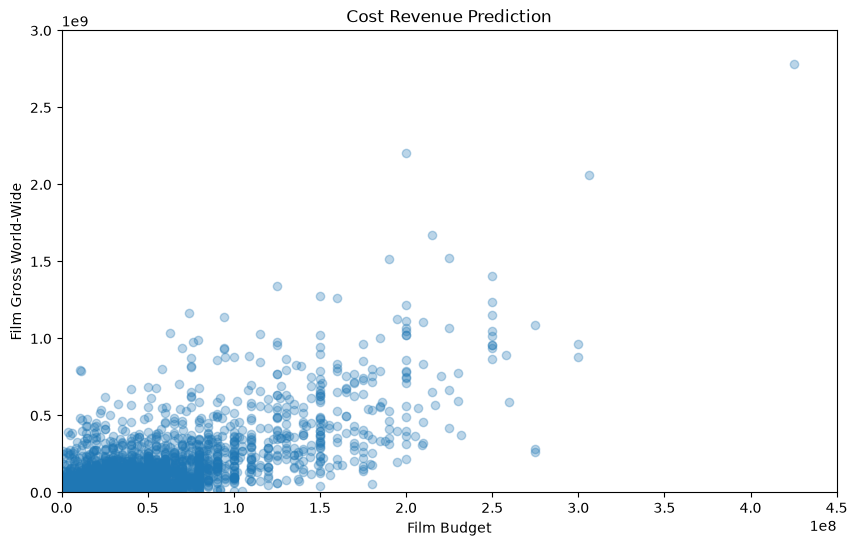

In [56]:
plt.figure(figsize=(10, 6))
plt.title("Cost Revenue Prediction")
plt.scatter(x, y, alpha=0.3)
plt.xlabel("Film Budget")
plt.ylabel("Film Gross World-Wide")
plt.xlim(0, 4.5e8)
plt.ylim(0, 3e9)
plt.show()

In [57]:
regression = skl.linear_model.LinearRegression()
regression.fit(x, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[3.11]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['production_budget_usd']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-7236192.73]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [58]:
coefficient = regression.coef_
intercept = regression.intercept_
predictions = regression.predict(x)
predictions

array([[-4.12468355e+06],
       [-7.20507764e+06],
       [-5.99158906e+06],
       ...,
       [ 9.44885617e+08],
       [ 6.15065644e+08],
       [ 1.31515521e+09]], shape=(5034, 1))

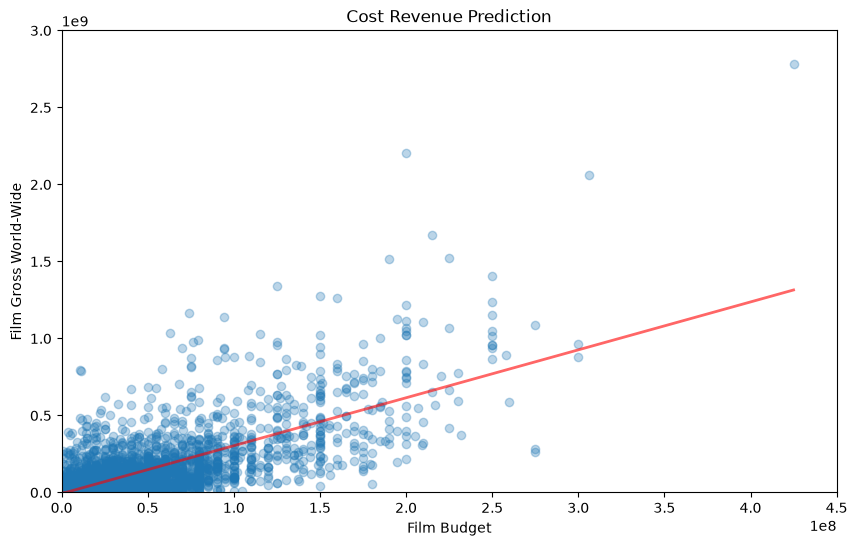

In [59]:
plt.figure(figsize=(10, 6))
plt.title("Cost Revenue Prediction")
plt.scatter(x, y, alpha=0.3)
plt.plot(x, predictions, alpha=0.6, color="red", linewidth=2)
plt.xlabel("Film Budget")
plt.ylabel("Film Gross World-Wide")
plt.xlim(0, 4.5e8)
plt.ylim(0, 3e9)
plt.show()

In [60]:
budget_new = 5e6
new_prediction = intercept + (coefficient * budget_new)
new_prediction = int(new_prediction.item())
new_prediction

8321353

In [61]:
score = regression.score(x, y)
score

0.5496485356985727